# Enron

### Data Training

In [36]:
import pandas as pd

df = pd.read_csv("Phishing_Emails/Enron.csv") #Enron


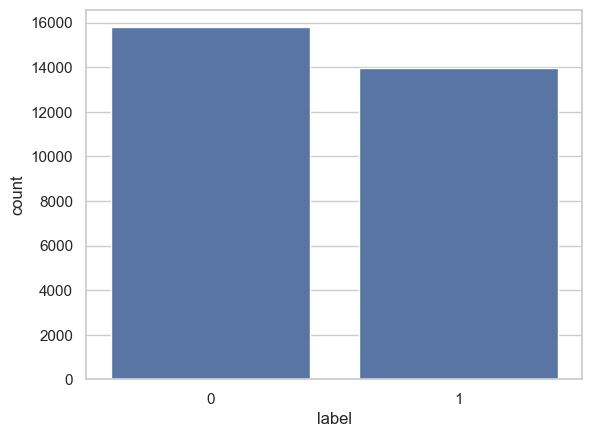

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

sns.countplot(data=df, x="label")
plt.show()


# Need to peroform clean up on data

In [38]:
import re

def clean_email(text):
    text = re.sub(r"From:.*\n", " ", text)      # remove headers
    text = re.sub(r"To:.*\n", " ", text)
    text = re.sub(r"Subject:.*\n", " ", text)
    text = re.sub(r"http\S+", " ", text)        # remove URLs
    text = re.sub(r"\S+@\S+", " ", text)        # remove email addresses
    text = re.sub(r"\d{1,2}/\d{1,2}/\d{2,4}", " ", text)  # remove dates
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def update_text(row):
    return clean_email( row['body'])
    

df['new_body'] = df.apply(update_text, axis=1)



# How to test for dataset bias
Simple diagnostic: Train classifier only on:​
- Email length​
- Vocabulary size​
- Proper noun count​
- Topic clusters​
- If performance remains high →​
You are detecting domain, not phishing.​

​

In [39]:
df["email_length"] = df["new_body"].str.len()
df["vocab_size"] = (
    df["body"]
    .str.lower()
    .str.findall(r"[a-z]+")
    .apply(lambda words: len(set(words)))
)




In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")

def proper_nouns(text):
    doc = nlp(text)
    return sum(1 for token in doc if token.pos_ == "PROPN")

df["proper_noun_count"] = df["new_body"].apply(proper_nouns)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

vectorizer = TfidfVectorizer(max_features=50)
X_tfidf = vectorizer.fit_transform(df["new_body"])

kmeans = KMeans(n_clusters=5, random_state=42)
df["topic_cluster"] = kmeans.fit_predict(X_tfidf)

In [ ]:
df.head()

,subject,body,label,new_col,email_length,vocab_size,new_body,topic_cluster
0,"hpl nom for may 25 , 2001",( see attached file : hplno 525 . xls )\r\n- h...,0,see attached file hplno xls hplno xls,37,5,see attached file hplno xls hplno xls,4
1,re : nom / actual vols for 24 th,- - - - - - - - - - - - - - - - - - - - - - fo...,0,forwarded by sabrae zajac hou ect on pm enron ...,1016,89,forwarded by sabrae zajac hou ect on pm enron ...,4
2,"enron actuals for march 30 - april 1 , 201","estimated actuals\r\nmarch 30 , 2001\r\nno flo...",0,estimated actuals march no flow march no flow ...,124,19,estimated actuals march no flow march no flow ...,3
3,"hpl nom for may 30 , 2001",( see attached file : hplno 530 . xls )\r\n- h...,0,see attached file hplno xls hplno xls,37,5,see attached file hplno xls hplno xls,4
4,"hpl nom for june 1 , 2001",( see attached file : hplno 601 . xls )\r\n- h...,0,see attached file hplno xls hplno xls,37,5,see attached file hplno xls hplno xls,4


## Feature Space

In [ ]:
features = ["email_length", "vocab_size", "topic_cluster"] #"proper_noun_count"
X = df[features]
y = df["label"]   # phishing vs legitimate

## Logistic Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.70      0.67      3185
           1       0.61      0.54      0.57      2769

    accuracy                           0.63      5954
   macro avg       0.62      0.62      0.62      5954
weighted avg       0.62      0.63      0.62      5954

